## Import data and transformation

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels
import sklearn 

Market_30yr = pd.read_csv("D:/Improvement Plan/Erdos Project/data/MORTGAGE30US.csv")
Treasure_10yr = pd.read_csv("D:/Improvement Plan/Erdos Project/data/DGS10.csv")
Housing_Activity = pd.read_csv("D:/Improvement Plan/Erdos Project/data/Housing Activity.csv")
WTI_record = pd.read_csv("D:/Improvement Plan/Erdos Project/data/DCOILWTICO.csv")
NewListing = pd.read_csv("D:/Improvement Plan/Erdos Project/data/NEWLISCOU26420.csv")
Employment = pd.read_csv("D:/Improvement Plan/Erdos Project/data/HOUS448UR.csv")
Permits = pd.read_csv("D:/Improvement Plan/Erdos Project/data/HOUS448BP1FH.csv")



# Housing_Activity.info()
Housing_Activity["Market Name"].unique()
Housing_Activity["Date"].agg(["min", "max"]) # 1990-01-01 to 2025-12-01 (monthly)

# Market_30yr.info()
Market_30yr["observation_date"].agg(["min", "max"]) # 1971-04-02 to 2026-02-12 (daily)

# Treasure_10yr.info()
Treasure_10yr["observation_date"].agg(["min", "max"]) # 1971-04-01 to 2026-02-13 (daily)

# NewListing.info()
NewListing["observation_date"].agg(["min", "max"]) # 2016-07-01 to 2026-01-01 (monthly)

# WTI_record.info()
WTI_record["observation_date"].agg(["min", "max"]) # 1986-01-02 to 2026-02-09 (daily)

# Employment.info()
Employment["observation_date"].agg(["min", "max"]) # 1990-01-01 to 2025-11-01 (monthly)

# Permits.info()
Permits["observation_date"].agg(["min", "max"]) # 1988-01-01 to 2025-10-01 (monthly)

### Convert to monthly
Housing_Activity["Date"] = pd.to_datetime(Housing_Activity["Date"])
Housing_Activity_monthly = (
    Housing_Activity.assign(date=pd.to_datetime(Housing_Activity["Date"]))
      .set_index("Date")
      .sort_index()
      .loc["2016-07-01":"2025-09-30"]
      .resample("M")
      .last()
      .assign(year_month=lambda x: x.index.to_period("M"))   # key like 2010-01
      .reset_index(drop=True)                                # optional: drop daily date index
)

Market_30yr["observation_date"] = pd.to_datetime(Market_30yr["observation_date"])
Market_30yr_monthly = (
    Market_30yr.set_index("observation_date")
      .sort_index()
      .resample("M")
      .last()
      .assign(
        year_month=lambda x: x.index.to_period("M"),
        # Shift by 12 for monthly data to get Year-over-Year change
        ten_yr_spread=lambda x: x["MORTGAGE30US"] - x["MORTGAGE30US"].shift(12)
      )
      .loc["2016-07-01":"2025-09-30"] # Filter AFTER calculating the shift
      .reset_index()
)

Treasure_10yr["observation_date"] = pd.to_datetime(Treasure_10yr["observation_date"])
Treasure_10yr_monthly = (
    Treasure_10yr.assign(date=pd.to_datetime(Treasure_10yr["observation_date"]))
      .set_index("observation_date")
      .sort_index()
      .loc["2016-07-01":"2025-09-30"]
      .resample("M")
      .last()
      .assign(year_month=lambda x: x.index.to_period("M"))   # key like 2010-01
      .reset_index(drop=True)                                # optional: drop daily date index
)

NewListing["observation_date"] = pd.to_datetime(NewListing["observation_date"])
NewListing_monthly = (
    NewListing.assign(date=pd.to_datetime(NewListing["observation_date"]))
      .set_index("observation_date")
      .sort_index()
      .loc["2016-07-01":"2025-09-30"]
      .resample("M")
      .last()
      .assign(year_month=lambda x: x.index.to_period("M"))   # key like 2010-01
      .reset_index(drop=True)                                # optional: drop daily date index
)

WTI_record["observation_date"] = pd.to_datetime(WTI_record["observation_date"])
WTI_record_monthly = (
    WTI_record.assign(date=pd.to_datetime(WTI_record["observation_date"]))
      .set_index("observation_date")
      .sort_index()
      .loc["2016-07-01":"2025-09-30"]
      .resample("M")
      .last()
      .assign(year_month=lambda x: x.index.to_period("M"))   # key like 2010-01
      .reset_index(drop=True)                                # optional: drop daily date index
)


Employment["observation_date"] = pd.to_datetime(Employment["observation_date"])
Employment_monthly = (
    Employment.assign(date=pd.to_datetime(Employment["observation_date"]))
      .set_index("observation_date")
      .sort_index()
      .loc["2016-07-01":"2025-09-30"]
      .resample("M")
      .last()
      .assign(year_month=lambda x: x.index.to_period("M"))   # key like 2010-01
      .reset_index(drop=True)                                # optional: drop daily date index
)

Permits["observation_date"] = pd.to_datetime(Permits["observation_date"])
Permits_monthly = (
    Permits.assign(date=pd.to_datetime(Permits["observation_date"]))
      .set_index("observation_date")
      .sort_index()
      .loc["2016-07-01":"2025-09-30"]
      .resample("M")
      .last()
      .assign(year_month=lambda x: x.index.to_period("M"))   # key like 2010-01
      .reset_index(drop=True)                                # optional: drop daily date index
)



In [2]:
# Housing_Activity_monthly.info()
Housing_Activity_monthly["year_month"].agg(["min", "max"])

min    2016-07
max    2025-10
Name: year_month, dtype: period[M]

In [3]:
# Market_30yr_monthly.info()
# Market_30yr_monthly["year_month"].agg(["min", "max"])
Market_30yr_monthly

,observation_date,MORTGAGE30US,year_month,ten_yr_spread
0,2016-07-31,3.48,2016-07,-0.50
1,2016-08-31,3.43,2016-08,-0.41
2,2016-09-30,3.42,2016-09,-0.44
3,2016-10-31,3.47,2016-10,-0.29
4,2016-11-30,4.03,2016-11,0.08
...,...,...,...,...
107,2025-06-30,6.77,2025-06,-0.09
108,2025-07-31,6.72,2025-07,-0.06
109,2025-08-31,6.56,2025-08,0.21
110,2025-09-30,6.30,2025-09,0.22


In [15]:
Treasure_10yr_monthly.info()
Treasure_10yr_monthly["year_month"].agg(["min", "max"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   DGS10       111 non-null    float64       
 1   date        111 non-null    datetime64[ns]
 2   year_month  111 non-null    period[M]     
dtypes: datetime64[ns](1), float64(1), period[M](1)
memory usage: 2.7 KB


min    2016-07
max    2025-09
Name: year_month, dtype: period[M]

In [16]:
NewListing_monthly.info()
NewListing_monthly["year_month"].agg(["min", "max"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   NEWLISCOU26420  111 non-null    int64         
 1   date            111 non-null    datetime64[ns]
 2   year_month      111 non-null    period[M]     
dtypes: datetime64[ns](1), int64(1), period[M](1)
memory usage: 2.7 KB


min    2016-07
max    2025-09
Name: year_month, dtype: period[M]

In [6]:
WTI_record_monthly.info()
WTI_record_monthly["year_month"].agg(["min", "max"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   DCOILWTICO  112 non-null    float64       
 1   date        112 non-null    datetime64[ns]
 2   year_month  112 non-null    period[M]     
dtypes: datetime64[ns](1), float64(1), period[M](1)
memory usage: 2.8 KB


min    2016-07
max    2025-10
Name: year_month, dtype: period[M]

In [7]:
Employment_monthly.info()
Employment_monthly["year_month"].agg(["min", "max"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   HOUS448UR   111 non-null    float64       
 1   date        112 non-null    datetime64[ns]
 2   year_month  112 non-null    period[M]     
dtypes: datetime64[ns](1), float64(1), period[M](1)
memory usage: 2.8 KB


min    2016-07
max    2025-10
Name: year_month, dtype: period[M]

In [8]:
Permits_monthly.info()
Permits_monthly["year_month"].agg(["min", "max"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   HOUS448BP1FH  112 non-null    int64         
 1   date          112 non-null    datetime64[ns]
 2   year_month    112 non-null    period[M]     
dtypes: datetime64[ns](1), int64(1), period[M](1)
memory usage: 2.8 KB


min    2016-07
max    2025-10
Name: year_month, dtype: period[M]

## Visualization

### Trend

- New Listing vs Rates

- New Listing vs WTI, Permits

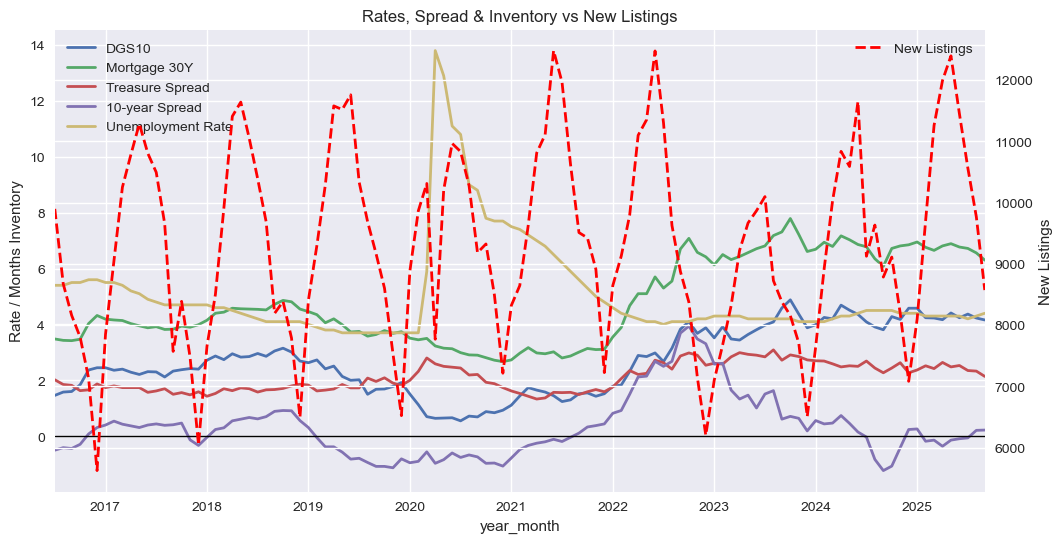

In [17]:
import matplotlib.pyplot as plt

EDA_data = (
    NewListing_monthly[["year_month","NEWLISCOU26420"]]
    .merge(Housing_Activity_monthly[["year_month","Months Inventory"]], on = "year_month", how = "left")
    .merge(Market_30yr_monthly[["year_month", "MORTGAGE30US", "ten_yr_spread"]], on = "year_month", how = "left")
    .merge(Treasure_10yr_monthly[["year_month", "DGS10"]], on = "year_month", how = "left")
    .merge(WTI_record_monthly[["year_month", "DCOILWTICO"]], on = "year_month", how = "left")
    .merge(Employment_monthly[["year_month", "HOUS448UR"]], on = "year_month", how = "left")
    .merge(Permits_monthly[["year_month", "HOUS448BP1FH"]], on = "year_month", how = "left")
)

EDA_data["treasure_spread"] = EDA_data["MORTGAGE30US"] - EDA_data["DGS10"]


# EDA_data["year_month"] = EDA_data["year_month"].dt.to_timestamp()
EDA_data = EDA_data.set_index("year_month")

### speard, 10-yr yield,  and new listings

plt.style.use("seaborn-v0_8")

fig, ax1 = plt.subplots(figsize=(12, 6))

# -------------------------
# LEFT AXIS
# -------------------------
EDA_data["DGS10"].plot(ax=ax1, label="DGS10", linewidth=2)
EDA_data["MORTGAGE30US"].plot(ax=ax1, label="Mortgage 30Y", linewidth=2)
EDA_data["treasure_spread"].plot(ax=ax1, label="Treasure Spread", linewidth=2)
EDA_data["ten_yr_spread"].plot(ax=ax1, label="10-year Spread", linewidth=2)
EDA_data["HOUS448UR"].plot(ax=ax1, label="Unemployment Rate", linewidth=2)
# EDA_data["Months Inventory"].plot(
#     ax=ax1, label="Months Inventory", linewidth=2, linestyle=":"
# )

ax1.set_ylabel("Rate / Months Inventory")
ax1.axhline(0, color="black", linewidth=1)
ax1.legend(loc="upper left")

# -------------------------
# RIGHT AXIS
# -------------------------
ax2 = ax1.twinx()

EDA_data["NEWLISCOU26420"].plot(
    ax=ax2,
    label="New Listings",
    color="red",
    linestyle="--",
    linewidth=2
)

ax2.set_ylabel("New Listings")
ax2.legend(loc="upper right")

# -------------------------
# TITLE & GRID
# -------------------------
ax1.set_title("Rates, Spread & Inventory vs New Listings")
ax1.grid(True)

plt.show()

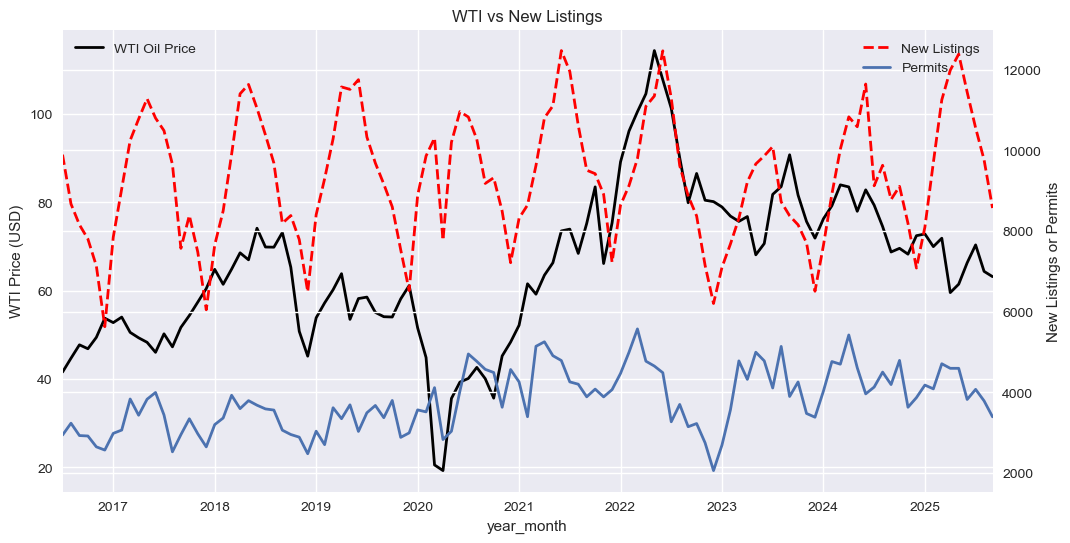

In [18]:
plt.style.use("seaborn-v0_8")

fig, ax1 = plt.subplots(figsize=(12, 6))

# -------------------------
# LEFT AXIS → WTI
# -------------------------
EDA_data["DCOILWTICO"].plot(
    ax=ax1,
    color="black",
    linewidth=2,
    label="WTI Oil Price"
)

ax1.set_ylabel("WTI Price (USD)")
ax1.legend(loc="upper left")
ax1.grid(True)

# -------------------------
# RIGHT AXIS → New Listings
# -------------------------
ax2 = ax1.twinx()

EDA_data["NEWLISCOU26420"].plot(
    ax=ax2,
    color="red",
    linestyle="--",
    linewidth=2,
    label="New Listings"
)
EDA_data["HOUS448BP1FH"].plot(ax=ax2, label="Permits", linewidth=2)

ax2.set_ylabel("New Listings or Permits")
ax2.legend(loc="upper right")

# -------------------------
# TITLE
# -------------------------
ax1.set_title("WTI vs New Listings")

plt.show()

## Modeling

### Times Series Model

- SARIMA time series model

- GLM model

- XGBoost

In [21]:
Model_data = EDA_data.reset_index()

# Extract year and month directly using the datetime accessor
Model_data['year'] = Model_data['year_month'].dt.year
Model_data['month'] = Model_data['year_month'].dt.month
Model_data.drop(columns=['year_month'], inplace=True)

cols = list(Model_data.columns)
# Remove the ones you want to move
cols.remove('year')
cols.remove('month')
# Reassemble: [Desired First] + [The Rest]
Model_data = Model_data[['year', 'month'] + cols]
Model_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              111 non-null    int64  
 1   month             111 non-null    int64  
 2   NEWLISCOU26420    111 non-null    int64  
 3   Months Inventory  111 non-null    float64
 4   MORTGAGE30US      111 non-null    float64
 5   ten_yr_spread     111 non-null    float64
 6   DGS10             111 non-null    float64
 7   DCOILWTICO        111 non-null    float64
 8   HOUS448UR         111 non-null    float64
 9   HOUS448BP1FH      111 non-null    int64  
 10  treasure_spread   111 non-null    float64
dtypes: float64(7), int64(4)
memory usage: 9.7 KB


In [30]:
### SARIMA

import pmdarima as pm
import sklearn
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. Define your Target and Covariates
y_ts = Model_data['NEWLISCOU26420']
# Note: Ensure these columns are numeric and have no NaNs
x_ts = Model_data[['ten_yr_spread', 'HOUS448UR', 'HOUS448BP1FH']]

# 2. Run Auto-ARIMA
auto_model = pm.auto_arima(
    y_ts, 
    X = x_ts,                
    seasonal = True,         
    m = 12,                  
    stepwise = True,         
    suppress_warnings = False, 
    error_action = "ignore", 
    trace = False             
)

print(auto_model.summary().tables[1])
print(f"Model AIC: {auto_model.aic():.2f}")
print(f"Model BIC: {auto_model.bic():.2f}")

f:\Miniconda3\envs\pydata\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
f:\Miniconda3\envs\pydata\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
f:\Miniconda3\envs\pydata\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
f:\Miniconda3\envs\pydata\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
f:\Miniconda3\envs\pydata\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
f:\Mi

                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
intercept       306.9666    175.549      1.749      0.080     -37.102     651.036
ten_yr_spread   147.6985    125.855      1.174      0.241     -98.972     394.369
HOUS448UR      -299.5016     41.194     -7.270      0.000    -380.241    -218.763
HOUS448BP1FH      0.1542      0.120      1.284      0.199      -0.081       0.390
ar.L1             0.8105      0.081     10.053      0.000       0.653       0.969
ma.L1            -0.1685      0.113     -1.495      0.135      -0.389       0.052
ma.L2             0.1972      0.116      1.698      0.089      -0.030       0.425
ar.S.L12          0.5650      0.112      5.053      0.000       0.346       0.784
ar.S.L24          0.2761      0.113      2.434      0.015       0.054       0.498
sigma2         3.311e+05   4.19e+04      7.893      0.000    2.49e+05    4.13e+05
Model AIC: 1772.

f:\Miniconda3\envs\pydata\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


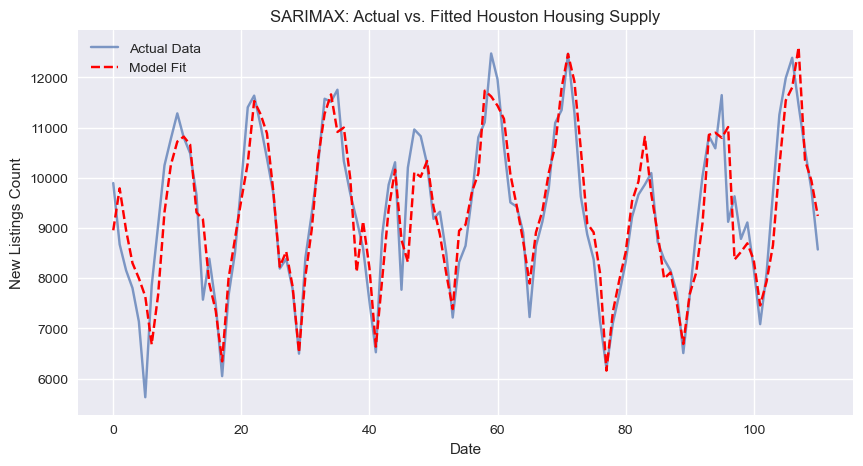

In [34]:
### Visualization Fix

# 1. Pass the original exogenous variables back into the function
# Make sure to use the 'cleaned' version if you dropped NaNs!
fitted = auto_model.predict_in_sample(X = x_ts) 

# 2. Plotting
plt.figure(figsize=(10, 5))

# Use the index from your cleaned data so the lengths match
plt.plot(y_ts.index, y_ts, label='Actual Data', alpha=0.7)
plt.plot(y_ts.index, fitted, label='Model Fit', color='red', linestyle='--')

plt.title('SARIMAX: Actual vs. Fitted Houston Housing Supply')
plt.xlabel('Date')
plt.ylabel('New Listings Count')
plt.legend()
plt.show()

### Negative Binomial GLM

In [27]:
### Negative Binomial GLM
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. Clean data to remove the shift-induced NaNs
Model_data_clean = Model_data.dropna(subset=['NEWLISCOU26420', 'month', 'ten_yr_spread', 'HOUS448UR', 'HOUS448BP1FH'])

# 2. Fit the model
# Note the change to sm.families.NegativeBinomial()
model_NBglm = smf.glm(formula="NEWLISCOU26420 ~ month + ten_yr_spread + HOUS448UR + HOUS448BP1FH", 
                data=Model_data_clean, 
                family=sm.families.NegativeBinomial()).fit()

print(model_NBglm.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:         NEWLISCOU26420   No. Observations:                  111
Model:                            GLM   Df Residuals:                      106
Model Family:        NegativeBinomial   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1125.1
Date:                Wed, 25 Feb 2026   Deviance:                       2.1735
Time:                        15:47:26   Pearson chi2:                     2.17
No. Iterations:                     5   Pseudo R-squ. (CS):           0.009335
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         8.8994      0.657     13.547

f:\Miniconda3\envs\pydata\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


### XGBoost

In [ ]:
# --- 1. Feature Engineering & Cleaning ---
Model_xgdata = Model_data.copy()
Model_xgdata['lag_1'] = Model_xgdata['NEWLISCOU26420'].shift(1)
Model_xgdata['lag_12'] = Model_xgdata['NEWLISCOU26420'].shift(12)
Model_xgdata['rolling_mean_3'] = Model_xgdata['NEWLISCOU26420'].shift(1).rolling(window=3).mean()

Model_xgdata_clean = Model_xgdata.dropna()

# --- 2. Chronological Split ---
split_index = len(Model_xgdata_clean) - 12
train = Model_xgdata_clean.iloc[:split_index]
test = Model_xgdata_clean.iloc[split_index:]

features = ['month', 'ten_yr_spread', 'HOUS448UR', 'lag_1', 'lag_12', 'rolling_mean_3']

X_train, y_train = train[features], train['NEWLISCOU26420']
X_test, y_test = test[features], test['NEWLISCOU26420']

In [48]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# We use a lower learning rate to make the curve smoother
model_xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=4,
    eval_metric="mae",
    early_stopping_rounds=50  # Stops training if Test error hasn't improved in 50 steps
)

model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)], # Sets up validation_0 and validation_1
    verbose=False
)

# Predict
predictions = model_xgb.predict(X_test)
print(f"Test MAE: {mean_absolute_error(y_test, predictions):.2f}")

Test MAE: 520.61


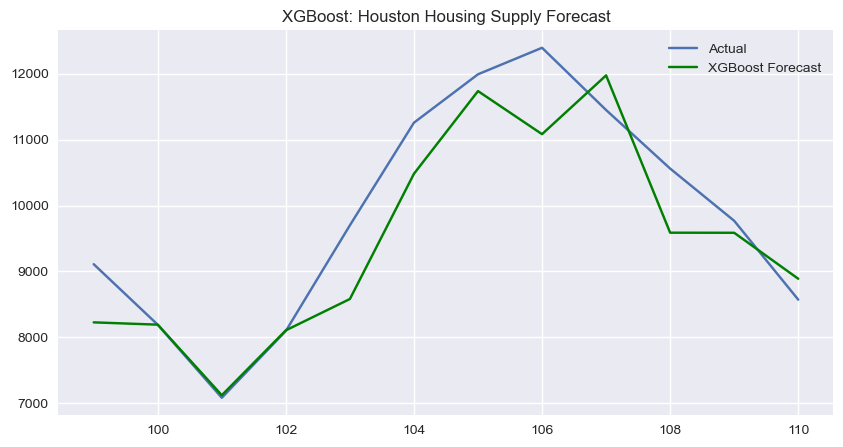

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(test.index, y_test, label='Actual')
plt.plot(test.index, predictions, label='XGBoost Forecast', color='green')
plt.title('XGBoost: Houston Housing Supply Forecast')
plt.legend()
plt.show()

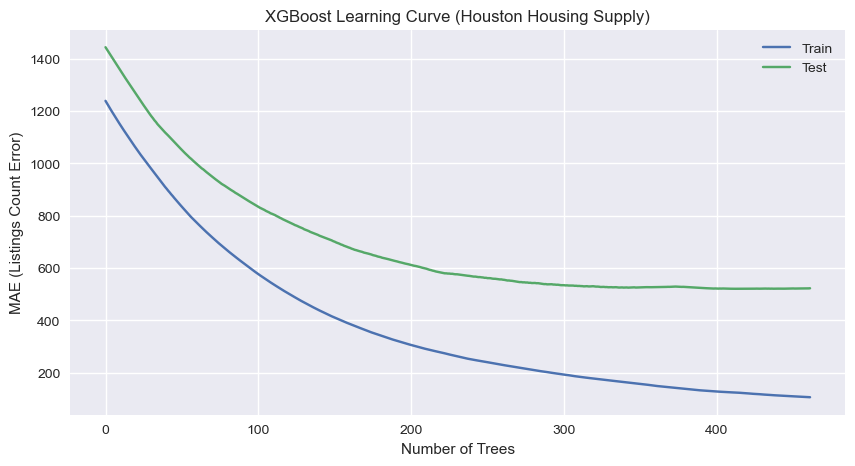

In [49]:
results = model_xgb.evals_result()
epochs = len(results['validation_0']['mae'])
x_axis = range(0, epochs)

plt.figure(figsize=(10, 5))
plt.plot(x_axis, results['validation_0']['mae'], label='Train')
plt.plot(x_axis, results['validation_1']['mae'], label='Test')
plt.title('XGBoost Learning Curve (Houston Housing Supply)')
plt.ylabel('MAE (Listings Count Error)')
plt.xlabel('Number of Trees')
plt.legend()
plt.show()

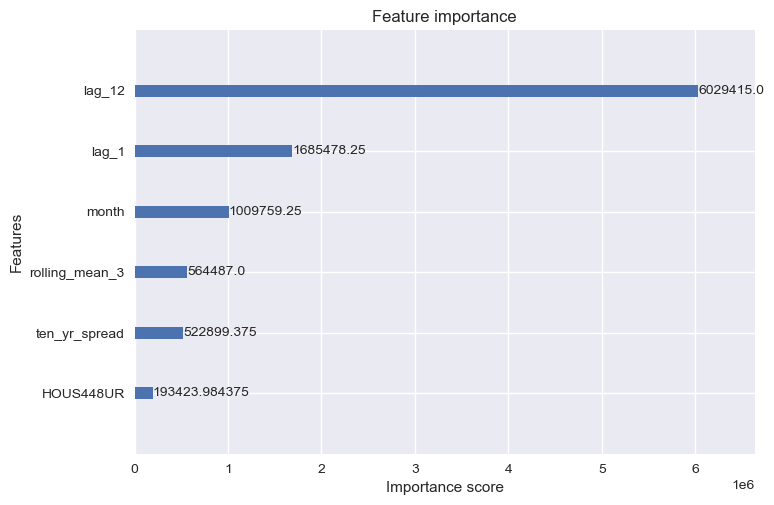

In [50]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

# This defaults to 'weight'
plot_importance(model_xgb, importance_type='gain') 
plt.show()